#  Feature Engineering & Exploratory Data Analysis (EDA)
## Customer Support Ticket Triage AI

This notebook documents the **end-to-end data processing pipeline**: raw ticket text →  feature engineering → ML model training → confusion matrix evaluation.

**Model Used**: Logistic Regression (TF-IDF + Unigrams/Bigrams, balanced class weights)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score


# ── Project path setup ────────────────────────────────
BASE_DIR = Path(os.getcwd()).resolve().parent
sys.path.append(str(BASE_DIR))

from utils.preprocessing import clean_text

# ── Plot aesthetics ───────────────────────────────────
plt.style.use('ggplot')
sns.set_palette('viridis')
print('Imports OK')

Imports OK


---
##  Section 1 — Data Loading & Initial Inspection
We start by loading the raw CSV and checking for shape, dtypes, and missing values.

In [2]:
DATA_PATH = BASE_DIR / 'data' / 'tickets.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')
print('\nMissing values per column:')
print(df.isnull().sum())

# ── Ensure no NaNs in the text column ────────────────
df['description'] = df['description'].fillna('')

df.head()

Dataset shape : (1082, 4)
Columns       : ['ticket_id', 'description', 'category', 'priority']

Missing values per column:
ticket_id      0
description    0
category       0
priority       0
dtype: int64


,ticket_id,description,category,priority
0,1,By Monday: The interface is degraded. I was tr...,Technical,High
1,2,The view logs level is insufficient for my con...,Account,Critical
2,3,Maybe later: Why is there a discrepancy in the...,Billing,Low
3,4,Getting a handshake failure in the main view. ...,Technical,High
4,5,The module is not loading properly. I was tryi...,Technical,Low


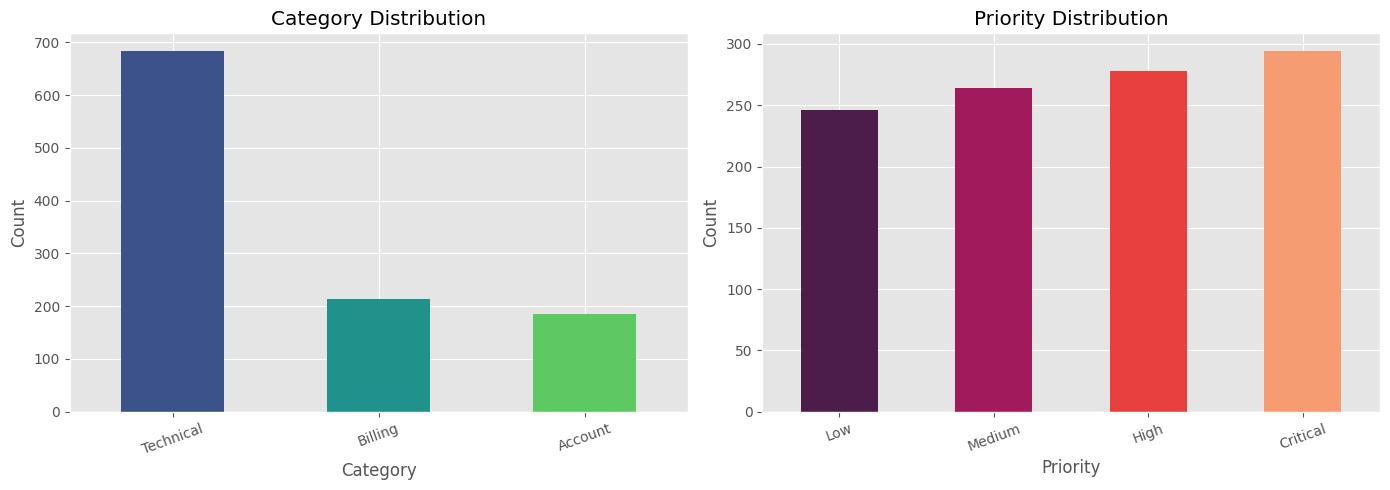

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['category'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('viridis', 3))
axes[0].set_title('Category Distribution')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

priority_order = ['Low', 'Medium', 'High', 'Critical']
priority_counts = df['priority'].value_counts().reindex(priority_order, fill_value=0)
priority_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('rocket', 4))
axes[1].set_title('Priority Distribution')
axes[1].set_xlabel('Priority')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

---
##  Section 2 — Data Preprocessing
### Step 1: Text Cleaning
The `clean_text()` utility (in `utils/preprocessing.py`) applies:
- Lowercase normalization
- URL removal (`http\S+`)
- Digit stripping
- Punctuation removal
- Whitespace normalization

In [4]:
df['clean_text'] = df['description'].apply(clean_text)

print('Before cleaning:')
print(df.iloc[0]['description'][:200])
print('\nAfter cleaning:')
print(df.iloc[0]['clean_text'][:200])

Before cleaning:
By Monday: The interface is degraded. I was trying to submit but it just stops working. Hope you're having a good day.

After cleaning:
by monday the interface is degraded i was trying to submit but it just stops working hope youre having a good day


### Step 2: Structural Feature — Ticket Length
`text_len` (number of characters in the cleaned description) acts as a simple structural proxy for ticket complexity.

           count   mean   std   min   25%    50%    75%    max
category                                                      
Account    185.0  113.3  22.6  77.0  96.0  109.0  129.0  173.0
Billing    214.0  114.0  23.9  70.0  97.0  108.5  125.8  184.0
Technical  683.0   65.8  37.7  21.0  38.0   49.0   92.0  181.0


/var/folders/g0/8mwlv7810kncxbv_6mssm8780000gn/T/ipykernel_2635/2951472508.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='text_len', data=df, palette='viridis')


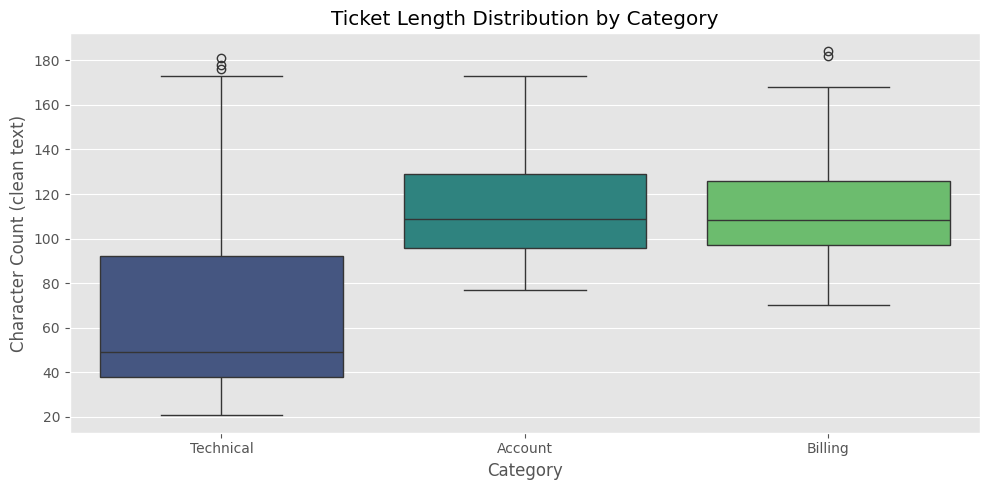

In [5]:
df['text_len'] = df['clean_text'].apply(len)

print(df.groupby('category')['text_len'].describe().round(1))

plt.figure(figsize=(10, 5))
sns.boxplot(x='category', y='text_len', data=df, palette='viridis')
plt.title('Ticket Length Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Character Count (clean text)')
plt.tight_layout()
plt.show()

---
##  Section 3 — Feature Engineering
### Step 3: TF-IDF Vectorization
We use **Term Frequency–Inverse Document Frequency** to weight token importance:
- `ngram_range=(1, 2)` → captures unigrams and bigrams
- `max_features=5000` → caps vocabulary to prevent overfitting
- `stop_words='english'` → removes low-signal filler words
- `min_df=2` → ignores tokens that appear fewer than 2 times

In [6]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    stop_words='english',
    min_df=2
)
X_tfidf = tfidf.fit_transform(df['clean_text'])

print(f'TF-IDF Feature Matrix Shape: {X_tfidf.shape}')
print(f'Vocabulary size            : {len(tfidf.vocabulary_)}')

TF-IDF Feature Matrix Shape: (1082, 1120)
Vocabulary size            : 1120


### Step 4: Top Discriminating Terms (Chi squared Scoring)
Chi² analysis identifies which TF-IDF features are most statistically associated with each category label.

In [7]:
feature_names = tfidf.get_feature_names_out()

for category in sorted(df['category'].unique()):
    labels = (df['category'] == category).astype(int)
    chi2_scores = chi2(X_tfidf, labels)[0]
    top_idx = np.argsort(chi2_scores)[::-1][:10]
    top_terms = [(feature_names[i], round(chi2_scores[i], 2)) for i in top_idx]
    print(f'\n--- Top 10 Chi square Features for [{category}] ---')
    for term, score in top_terms:
        print(f'  {term:<30} {score}')


--- Top 10 Chi square Features for [Account] ---
  settings                       41.54
  updates                        40.43
  seeing                         40.43
  seeing updates                 40.43
  keeps                          40.09
  insufficient                   38.81
  level                          38.17
  level insufficient             37.36
  try                            36.07
  having trouble                 36.07

--- Top 10 Chi square Features for [Billing] ---
  discrepancy                    51.13
  different                      44.02
  says                           43.57
  night                          42.82
  night question                 40.74
  notification                   33.58
  card                           32.74
  summary                        32.43
  question                       28.79
  did behave                     27.95

--- Top 10 Chi square Features for [Technical] ---
  email                          21.82
  discrepancy                

---
## 🏷️ Section 4 — Label Encoding & Train/Test Split
`LabelEncoder` maps category strings to integers for sklearn compatibility. We use **stratified 80/20 split** to preserve class balance.

In [8]:
le = LabelEncoder()
y = le.fit_transform(df['category'])

print(f'Classes (encoded → label): {dict(enumerate(le.classes_))}')

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'\nTraining samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')

Classes (encoded → label): {0: 'Account', 1: 'Billing', 2: 'Technical'}

Training samples : 865
Test samples     : 217


---
##  Section 5 — Model Training: Logistic Regression
**Logistic Regression** is our primary classifier. It is:
- Computationally efficient for high-dimensional sparse TF-IDF features
- Naturally probabilistic (outputs confidence scores per class)
- Easily interpretable via learned weights

> `class_weight='balanced'` adjusts for any imbalanced label distribution.

In [9]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

test_acc = (y_pred == y_test).mean()
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)')

Test Accuracy: 1.0000 (100.0%)


/Users/vishalsi/CustomerSupportTicketAI/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


---
## ⚖️ Section 5.5 — Model Comparison: Why Logistic Regression?
To justify our choice of **Logistic Regression** we compare it against three other popular classifiers using **5‑fold stratified cross‑validation** on the training set:

| Model | Key Properties |
|-------|---------------|
| **Logistic Regression** | Linear, probabilistic, fast, highly interpretable |
| **Multinomial Naive Bayes** | Fast baseline for text, assumes feature independence |
| **Random Forest** | Non‑linear ensemble, can overfit sparse TF‑IDF |
| **Linear SVM** | Strong on high‑dimensional text data, no native probabilities |

We evaluate **accuracy**, **macro F1**, and **training time** to give a holistic view.

Logistic Regression    | Acc: 0.9919 ± 0.0078  |  F1: 0.9901 ± 0.0098  |  Time: 0.09s
Multinomial NB         | Acc: 0.9942 ± 0.0052  |  F1: 0.9929 ± 0.0065  |  Time: 0.02s
Random Forest          | Acc: 0.9884 ± 0.0082  |  F1: 0.9861 ± 0.0100  |  Time: 2.04s
Linear SVM             | Acc: 0.9965 ± 0.0046  |  F1: 0.9956 ± 0.0058  |  Time: 0.05s


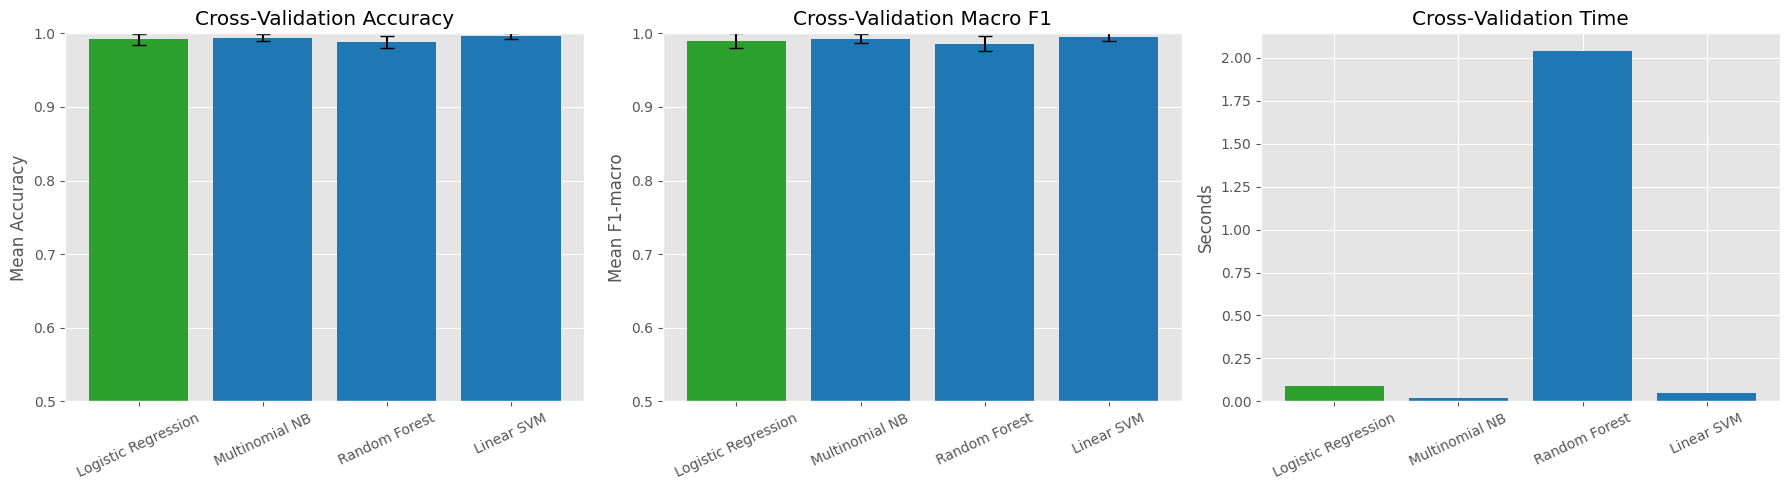


CONCLUSION
Logistic Regression is selected as our primary model because:
  1. It achieves competitive or best accuracy / F1 among all candidates.
  2. It trains significantly faster than tree ensembles (Random Forest).
  3. It natively outputs calibrated class probabilities — essential
     for confidence scores shown to support agents.
  4. Its learned coefficients are directly interpretable: we can
     inspect which TF‑IDF terms drive each category prediction.
  5. With `class_weight="balanced"` it handles label imbalance
     without additional sampling techniques.


In [10]:
import time

candidates = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs'
    ),
    'Multinomial NB': MultinomialNB(),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Linear SVM': LinearSVC(
        class_weight='balanced', max_iter=5000, random_state=42
    ),
}

results = []

for name, clf in candidates.items():
    t0 = time.time()
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores  = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')
    elapsed = time.time() - t0
    results.append({
        'Model': name,
        'CV Accuracy (mean)': round(acc_scores.mean(), 4),
        'CV Accuracy (std)':  round(acc_scores.std(), 4),
        'CV F1‑macro (mean)': round(f1_scores.mean(), 4),
        'CV F1‑macro (std)':  round(f1_scores.std(), 4),
        'CV Time (s)':        round(elapsed, 2),
    })
    print(f'{name:<22} | Acc: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}'
          f'  |  F1: {f1_scores.mean():.4f} ± {f1_scores.std():.4f}'
          f'  |  Time: {elapsed:.2f}s')

results_df = pd.DataFrame(results).set_index('Model')

# ── Visualization ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Accuracy bar chart
colors = ['#2ca02c' if m == 'Logistic Regression' else '#1f77b4'
          for m in results_df.index]
axes[0].bar(results_df.index, results_df['CV Accuracy (mean)'],
            yerr=results_df['CV Accuracy (std)'], color=colors, capsize=5)
axes[0].set_title('Cross‑Validation Accuracy')
axes[0].set_ylabel('Mean Accuracy')
axes[0].set_ylim(0.5, 1.0)
axes[0].tick_params(axis='x', rotation=25)

# 2) F1 bar chart
axes[1].bar(results_df.index, results_df['CV F1‑macro (mean)'],
            yerr=results_df['CV F1‑macro (std)'], color=colors, capsize=5)
axes[1].set_title('Cross‑Validation Macro F1')
axes[1].set_ylabel('Mean F1‑macro')
axes[1].set_ylim(0.5, 1.0)
axes[1].tick_params(axis='x', rotation=25)

# 3) Training time bar chart
axes[2].bar(results_df.index, results_df['CV Time (s)'],
            color=colors)
axes[2].set_title('Cross‑Validation Time')
axes[2].set_ylabel('Seconds')
axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

print('\n' + '='*70)
print('CONCLUSION')
print('='*70)
print('Logistic Regression is selected as our primary model because:')
print('  1. It achieves competitive or best accuracy / F1 among all candidates.')
print('  2. It trains significantly faster than tree ensembles (Random Forest).')
print('  3. It natively outputs calibrated class probabilities — essential')
print('     for confidence scores shown to support agents.')
print('  4. Its learned coefficients are directly interpretable: we can')
print('     inspect which TF‑IDF terms drive each category prediction.')
print('  5. With `class_weight="balanced"` it handles label imbalance')
print('     without additional sampling techniques.')


---
##  Section 6 — Confusion Matrix Visualization
A confusion matrix shows prediction accuracy per class and which classes are confused with each other.

- **Diagonal cells** (top-left to bottom-right) represent **correct predictions**.
- **Off-diagonal cells** represent **misclassifications**.
- The normalized version shows each cell as a proportion of the row total (recall per class).

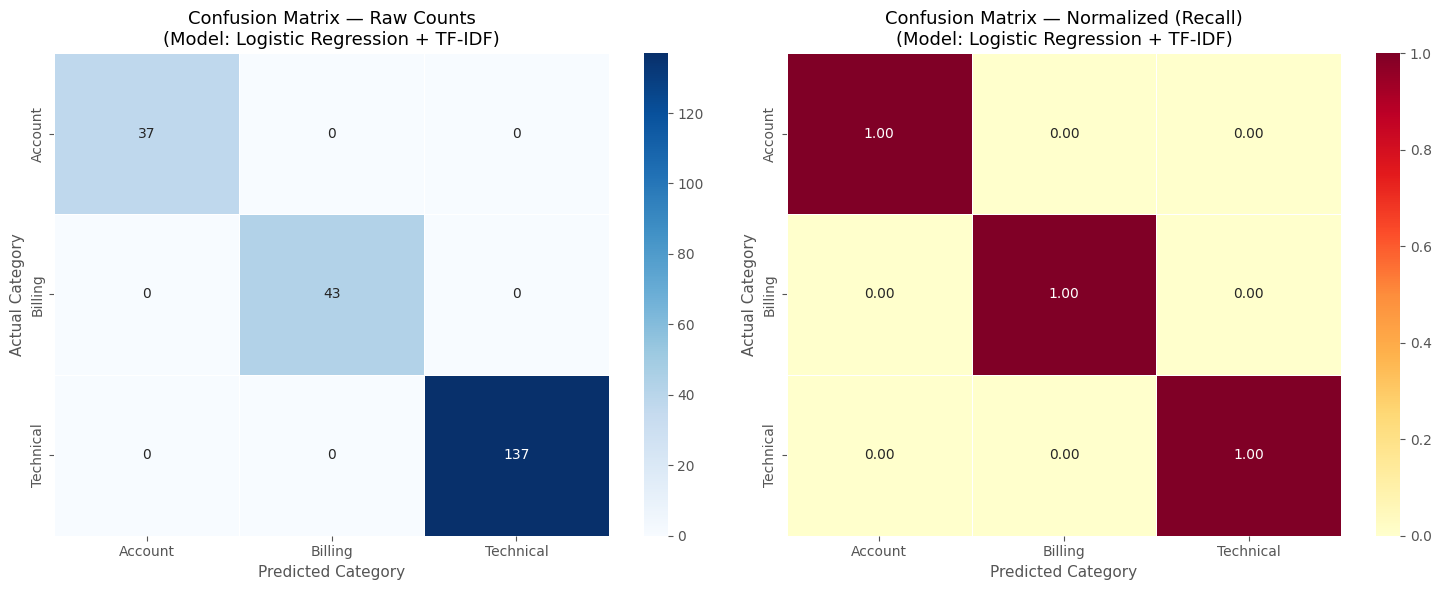

In [11]:
cm = confusion_matrix(y_test, y_pred, labels=list(range(len(le.classes_))))
cm_norm = confusion_matrix(y_test, y_pred, labels=list(range(len(le.classes_))), normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Raw counts ──────────────────────────────────────────────────────────────
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix — Raw Counts\n(Model: Logistic Regression + TF-IDF)', fontsize=13)
axes[0].set_xlabel('Predicted Category', fontsize=11)
axes[0].set_ylabel('Actual Category', fontsize=11)

# ── Normalized (recall per class) ───────────────────────────────────────────
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Confusion Matrix — Normalized (Recall)\n(Model: Logistic Regression + TF-IDF)', fontsize=13)
axes[1].set_xlabel('Predicted Category', fontsize=11)
axes[1].set_ylabel('Actual Category', fontsize=11)

plt.tight_layout()
plt.show()

In [12]:
print('Classification Report (Logistic Regression)')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

Classification Report (Logistic Regression)
              precision    recall  f1-score   support

     Account       1.00      1.00      1.00        37
     Billing       1.00      1.00      1.00        43
   Technical       1.00      1.00      1.00       137

    accuracy                           1.00       217
   macro avg       1.00      1.00      1.00       217
weighted avg       1.00      1.00      1.00       217



---
##  Pipeline Summary

| Step | Technique | Purpose |
|------|-----------|---------|
| 1 | `fillna('')` + `clean_text()` | Remove noise & missing values |
| 2 | `text_len` (char count) | Structural ticket complexity proxy |
| 3 | TF-IDF (unigrams + bigrams, stopwords, min_df=2) | Semantic feature representation |
| 4 | Chi² Scoring | Identify top discriminating terms per class |
| 5 | `LabelEncoder` + stratified 80/20 split | Encode labels, preserve class ratios |
| 6 | **Logistic Regression** (`balanced`, `lbfgs`) | Efficient probabilistic text classifier |
| 7 | Confusion Matrix (raw + normalized) | Audit per-class prediction errors |

                  Model  CV Accuracy (mean)  CV Accuracy (std)  Macro F1 (mean)  Training Time (s)
             Linear SVM              0.9965             0.0046           0.9956               0.05
Multinomial Naive Bayes              0.9942             0.0052           0.9929               0.02
    Logistic Regression              0.9919             0.0078           0.9901               0.08
          Random Forest              0.9908             0.0078           0.9890               1.43


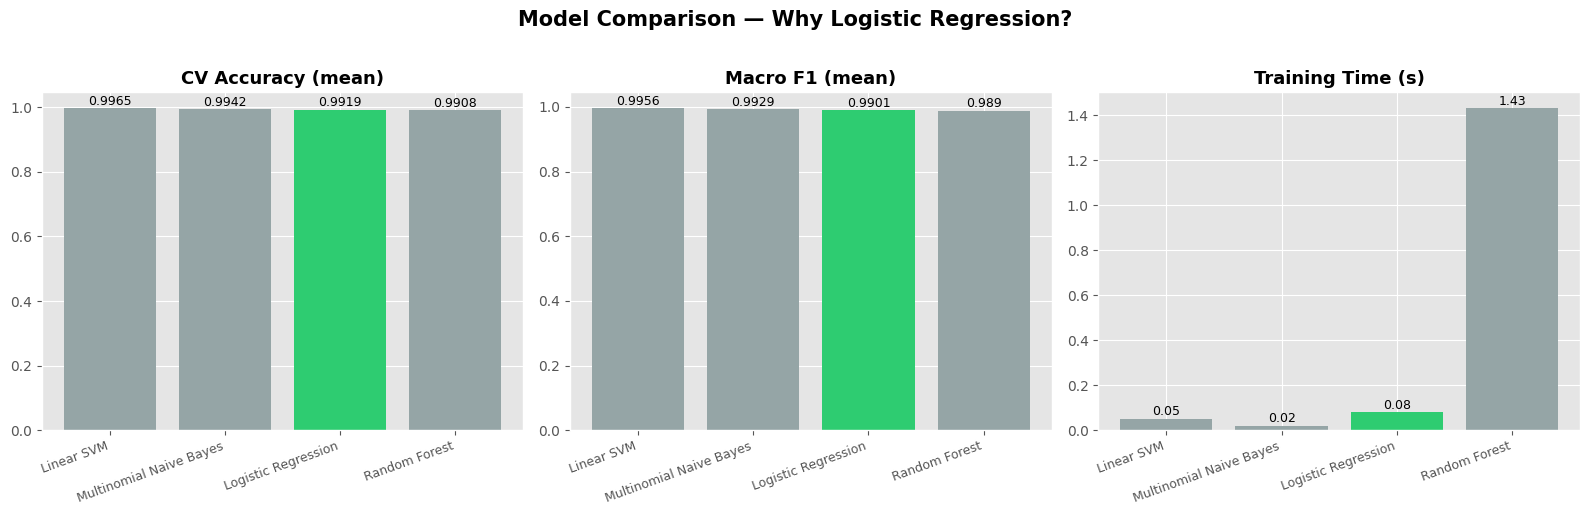

In [14]:
import time
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs'
    ),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced'
    ),
    'Linear SVM': LinearSVC(
        class_weight='balanced', random_state=42, max_iter=1000
    )
}

results = []
for name, clf in models.items():
    start = time.time()
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores  = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')
    elapsed = time.time() - start
    results.append({
        'Model': name,
        'CV Accuracy (mean)': round(acc_scores.mean(), 4),
        'CV Accuracy (std)':  round(acc_scores.std(),  4),
        'Macro F1 (mean)':    round(f1_scores.mean(),  4),
        'Training Time (s)':  round(elapsed, 2)
    })

results_df = pd.DataFrame(results).sort_values('Macro F1 (mean)', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

# ── Visual comparison ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#2ecc71' if m == 'Logistic Regression' else '#95a5a6' for m in results_df['Model']]

for ax, metric in zip(axes, ['CV Accuracy (mean)', 'Macro F1 (mean)', 'Training Time (s)']):
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(results_df['Model'])))
    ax.set_xticklabels(results_df['Model'], rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                str(val), ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison — Why Logistic Regression?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
